<a href="https://colab.research.google.com/github/pressleydavid/hw5/blob/main/HW5_DavidPressley_ST554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW5
**David Pressley**

**Course:** ST554

**Due:** March 3, 2026  

**Submission:** Save to GitHub repo, submit repo link on Moodle

**Instructions:**
- Include markdown text describing what you are doing, even when not explicitly asked for
- Save updates to GitHub as you work through it
- No edits after the due date

In [22]:
# import ability to use Markdown in Code Cell displays
from IPython.display import display, Markdown

---
## Part I:  Concepts

### Q1

*Give an example of a place where you've encountered big data or a topic you are interested in where big data would arise. Specifically address the five V's for the example and whether/how they apply to your example*

In my work in the clinical data sciences, I often address data at a large scale for the monitoring of adverse events in clinical trials. Pharmacovigilance intends to detect, assess, and mitigate the risks of adverse events of pharmaceutical products.

Over the summer, I was selected to be part of the first cohort of the American Tech Fellowship, an intensive course that went deep into the functionality of an AI platform capable of meeting the computational and security needs for big data concerns. As part of my capstone project, I created a data pipeline of notional, but representative data, an ontology for the key outcomes, RAG embeddings for care and treatment regimens, and predictive analytics to predict clinical worsening for patients with Duchenne Muscular Dystrophy.

At the center of the broader pharmacovigilance ("drug safety") ecosystem is FDA's Adverse Event Reporting System (FAERS).


---



**Volume**

FAERS contains over 20 million adverse event reports dating back to 2004, with quarterly data file releases of up to ~140MB of compressed data per table, and 7 relational tables. This is just the US reporting system. There are other global reporting systems that aggregate data from the EMA and WHO.

Though pharma Luddites will try to manage this data in spreadsheets, the volume quickly compounds.



---



**Velocity**

Regulatory reporting SLA's under federal regulations (21 CFR 312.32) legally bind firms to report fatal or life-threatening, unexpected adverse reactions within 7 calendar days. Missing these deadlines carries regulatory consequences to business operations and potential reputational harm, which can be significantly detrimental to a clinical development program with significant investment by creditors and shareholders, often reaching hundreds of millions of dollars over the course of multiple years.

From a data velocity perspective, this means as adverse event data flows from clinical sites into systems of record owned by pharma companies, rapid detection of what constitutes a Suspected, Unexpected, Serious Adverse Reaction is essential. So essential in fact, that it commands its own acronym: The SUSAR Report.

My capstone project was focused on using AI to compress a process that takes a firm's entire drug safety team days of manual work. Late nights, pizzas, yelling, crying, etc.

The velocity of streaming data can be relatively slow, because most adverse events don't cause such high velocity, but volume remains high.

---

**Variety**

The data involved spans:

- Structured tabular data: Bioanalytical lab results
- Unstructured text: physician narratives describing adverse events, clinical notes, investigator assessments, and other free-text fields.
- Biomarker and Genomic data: RNA, DNA, and protein biomarkers are often large and require transforming into usable formats for reporting purposes.

---

**Veracity**

Veracity is the most consequential of V's because poor data quality can be life-threatening to patient safety.

- FAERS is an open-reporting system: It's estimated that only a fraction of adverse events are ever reported to FAERS
- Duplicate Reporting: The same event may be reported through multiple channels,requiring de-duplication efforts. These are largely mitigated by often only addressing systems of record internal to the firm.
- Causaility discernment: Determining whether a drug caused en adverse event or merely coincidental currently requires a physician-in-the-loop who understands the disease domain, patterns, baseline patient characteristics, etc.
- Coding inconsistency: data captured in free text must be mapped to standardized medical coding terms.

Determining signal from noise is a problem.

---

**Value**

The entire point of using big data in the life sciences is to extract value to protect patients and shareholder value. In my project, the value proposition was to detect hepatotoxicity 4-8 weeks earlier by using biomarker monitoring using micro-RNA fragment 122, which is a liver specific micro-RNA.

RAG embedded journal articles for the care and treatment of Duchenne's Muscular Dystrophy provided a basis for my thesis and a foundation for the creation of an agent to query the closed-universe of literature on the topic and provide alerts to physicians.

miR-122 fragments are degradation products predictive of clinical worsening in DMD patients. Fold changes greater than 10x baseline showed a correlation with fatal outcomes of 0.89 in trial data, representing an early warning signal that could trigger intervention before irreversible organ damage occurs.

While this was merely a capstone project with notional data, it opened my eyes to what it means to "build downstream of value creation". Big Data is only worthwhile if you can extract meaningful, predictible outcomes from it. A traditional drug safety system that generates quarterly reports and pie charts documents what already happened. Building downstream of value means building systems that are capable of predicting adverse patient outcomes to protect patients from harm and ensure shareholder value.


### Q2

*Read about the database we'll use below (Part IV). Give an example for each letter in the CRUD acronym in the context of this database.*

- **Create**: for a new expansion team being included in the league, you would use `INSERT` to insert a new row in the `Teams` table
- **Read**: Querying the `HallofFame` table to find all players inducted
- **Update**: After a game concludes, you would use `UPDATE` to update the Team stats, and player statistics
- **Delete**: if a player's Hall of Fame induction were revoked for say,,, gambling, or sliding head first into third base all the time, `DELETE` would delete the record

### Q3

*What is the purpose of the `HAVING` clause when writing SQL code? (Recall the sqlitetutorial.net tutorial on the SELECT statement.)*

The `HAVING` clause filters results of a `GROUP BY` aggregation. By contrast, `WHERE` filters rows before a grouping occurs, while `HAVING` filters after a grouping aggregation.

As an example, finding all the managers who managed more than 10 seasons requires an aggregation of seasons first before a test can be made. `WHERE` won't work because it filters before aggregation. `HAVING` works because it works after the aggregation of seasons.

---
## Part II — Simulation of a Sampling Distribution (20 pts)

We looked at using simulation to investigate the sampling distribution of $\hat{p}$ in the notes. We'll now look at the sampling distribution of the sample slope from an SLR model using simulation.

Recall we assume the following model for SLR:

$$Y_i = \beta_0 + \beta_1 x_i + E_i$$

where the $E_i$ are assumed to be independent and identically distributed from a Normal distribution with mean 0 and variance $\sigma^2$. Let's assume $\sigma^2 = 1$ for simplicity.

We can generate data from this model by assuming values for $\beta_0$, $\beta_1$, and $n$, along with a sequence of $x$ values via the following code:

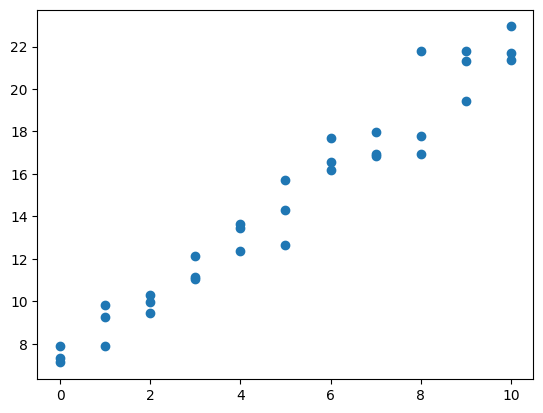

In [ ]:
#import  modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng

rng = default_rng(32)

beta_0 = 7
beta_1 = 1.5

# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33

#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)

#visualize the data
plt.scatter(x = x, y = y)
plt.show()

Now we can use `sklearn` to obtain the estimate for the slope (and save that value) as we did earlier in the course.

**Repeat the above process 5000 times. To be specific:**
- Generate the $y$ values using the code with `rng.standard_normal()`
- Find the 'best' slope via `sklearn`
- Save that slope in some object

In [21]:
from sklearn import linear_model

# set seed for consistent values
rng = default_rng(42)

# number of simulations
num_sims = 5000

# array to store the slope from each simulation
slopes = np.empty(num_sims)

# instantiate the linear regression model
reg1 = linear_model.LinearRegression()

# run the simulation
for i in range(num_sims):
    # generate new y values (x, beta_0, beta_1, n are the same each time)
    y = beta_0 + beta_1*x + rng.standard_normal(n)

    # Fit the linear regression using sklearn
    reg1.fit(x.reshape(-1, 1), y)

    # Save the estimated slope
    slopes[i] = reg1.coef_[0]

best_slope = slopes.mean()
print(f"Mean of slopes: {slopes.mean():.4f}")
print(f"Std dev of slopes: {slopes.std():.4f}")

Mean of slopes: 1.4999
Std dev of slopes: 0.0549


We can use the many values of the sample slope as an approximation to the sampling distribution of the sample slope! **Create a histogram of the sample slope values you found.** (3 pts)

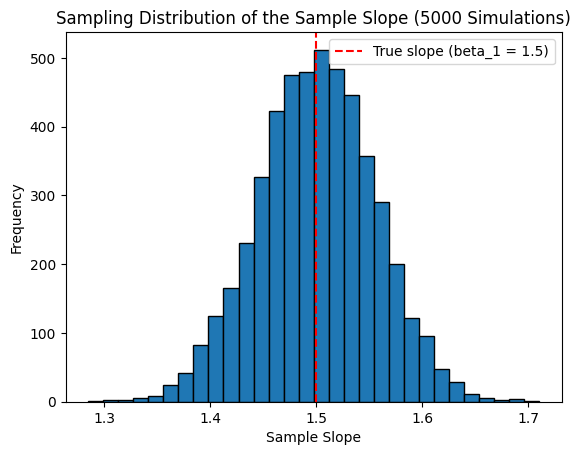

In [7]:
# Histogram of the simulated sample slopes
plt.hist(slopes, bins=30, edgecolor='black')
plt.xlabel("Sample Slope")
plt.ylabel("Frequency")
plt.title("Sampling Distribution for 5000 Simulations")

plt.axvline(x=1.5, color='red', linestyle='--', label=f"Slope (beta_1 = {beta_1})")
plt.legend()
plt.show()

**Use your sampling distribution to approximate the probability of observing a sample slope larger than 1.65.** This can be done by looking at the proportion of simulated values larger than 1.65. (3 pts)

In [8]:
# Approximate the probability of observing a sample slope larger than 1.65
prob = np.mean(slopes > 1.65)
print(f"P(sample slope > 1.65) = {prob:.4f}")

Approximate P(sample slope > 1.65) = 0.0028


**Give an interpretation of this value and why it might be important for us in relation to a hypothesis test.** (3 pts)

This small probability (0.0028) suggests that if the true slope is 1.5, observing a sample slope of 1.65 or larger by random chance alone is very unlikely (about 0.3% of the time). In a hypothesis testing context, under the null hypothesis of beta_1 = 1.5, obtaining a slope of 1.65 would be very unlikey, providing evidence against the null.

---
## Part III — Big Data Examples & Rare Events

### Q5

*Consider [this article about bias in machine learning models](https://hbr.org/2019/10/what-do-we-do-about-the-biases-in-ai).*

- *Pick an example in the article and briefly outline the issue around the data used to fit the model. (3 pts)*
- *Describe how we might augment the data or otherwise account for the bias in that situation. (3 pts)*


The article describes how Amazon built an ML model to screen job applicant resumes and identify top candidates. The company had historically hired more men than women for technical roles, and the model was trained on that same historical hiring data, which reflected years of implicit gender bias. As a result, the algorithm learned to penalize resumes containing the word "women" (e.g., "women's chess club captain"), systematically downranking female applicants. The training data itself encoded the bias, so the model simply reproduced and amplified existing inequality rather than making objective hiring decisions.

To address this, the training data could be updated to include a more balanced representation of male and female candidates, or other features related to gender (names, gendered terms, women's colleges) could be removed or masked before training. Additionally, in keeping with a best practice of human-in-the-loop, the model outputs could be audited for differences across demographic groups to ensure algorithmic predictions don't systematically disadvantage any group. More fundamentally, the article suggests that if the engineers evaluating the data had included more women, the bias might have been caught earlier.  

### Q6

*Consider [this article about big data usage in the Earth Sciences](https://www.frontiersin.org/articles/10.3389/feart.2022.982282/full).*

*Choose one of the three major areas the paper discusses. Summarize the use of big data there. Are there any biases or other missing data that might affect results? (Just do your best — the goal is to always ask questions about the data collected and used for a study!)*

The Vance et al. paper highlights how big data has improved surface water mapping and flood prediction through various models that combine high-resolution Digital Elevation Models with streamflow data across millions of river reaches. The paper goes on to acknowledge that the underlying elevation data contain "unavoidable data gaps and inconsistencies." Hurricane Helene in September 2024 exposed just how significant these gaps can be. In western NC, the interaction between Gulf moisture and the Blue Ridge escarpment produced prolonged, concentrated rainfall that funneled into the French Broad River system creatina a rare event that on one hand is poorly represented in historical flood records, and on the other was reasonably, anecdotally predictable. Big rains from a summer thunderstorm can flood the smaller tributaries rivers, and hurricanes have often caused significant debris flows on the steeper ridges. As a supplement to the article, for additonal context, [this video](https://youtu.be/oBuJxHR4ycY?si=smUcZvVGcWLVRGb4) provides more pictures than thousands of words could describe. Beyond water flooding, geologist Philip Prince documented debris flows that reached 60+ feet above stream channels and traveled at tens of miles per hour, behaving more like liquids than traditional landslides. Standard water-based flood models like HAND have no mechanism to predict this behavior. As a result, only ~2% of impacted properties were in FEMA flood zones. This suggests the models are biased toward typical precipitation patterns and coastal flooding scenarios, and lack the geological and subsurface variables needed to capture rare inland extremes where topography amplifies both rainfall and its destructive effects. In the video, around the 5 minute mark, he reaches the top of the mountain where the debris flows started. [You'll notice the lack of steepness of the slope.](https://youtu.be/oBuJxHR4ycY?si=go6XlhEEVZZdbRWR&t=345) and his mention that an extreme amount of rainfall is required to cause a debris flow like this.

The paper also discusses digital twins (DTs) of the Earth system, which aim to mirror real-world conditions and autonomously acquire new data to improve predictions. The paper emphasizes that a DT's accuracy is "highly reliant on the quality of the data and the analysis that it incorporates." Helene and the video at ~6:30 illustrates this reliance very clearly. If the underlying flood models and DEMs that feed a digital twin don't account for things like subsurface geology, slope, and topographic rainfall amplification, then the DT inherits those same blind spots. For digital twins to fulfill their promise in surface hydrology (or any other application), they would need to integrate not just water-level data but also geological variables like soil saturation, colluvial structure, and slope stability. The very factors that made Helene's impact so catastrophic and so poorly scientifically predicted, except by the Granny Witches of the region. They knew it was coming but their incantations in haunted tongues went unheard and unanswered.

### Q7

*Read through [this short article](https://magazine.amstat.org/blog/2023/11/01/rareevents/).*

*Mostly I just want you to read this article to understand some ways in which rare events, and statisticians, play a role in different places. Can you think of another variable or scenario where understanding rare events is important?*

The most shocking rare event that I have experienced was Hurricane Helene. I grew up where the largest impacts in Western North Carolina were realized, 5 miles from Lake Lure, and 15 miles from Asheville. We knew it was going to be bad days before it hit as the system itself was slinging water from the Gulf of Mexico into the mountains days in advance. The role of how best to use data to generate information and insights has certainly captured my curiosity, as virtually every system we've considered well-understood has seemingly taken at least 3 standard deviations from normal (or lognormal, as it were).

---
## Part IV — Querying a Database

There is a database file on the assignment link called `Lahman.db` that is an SQLite database [downloaded from here](https://github.com/jknecht/baseball-archive-sqlite). This database has information on Major League Baseball.

### Q8

**Connect to the database** (probably by uploading to Colab) and then look at all of the tables in the database (use `read_sql()` from `pandas` to have this returned as a data frame).

In [14]:
import pandas as pd
import sqlite3
import urllib.request

url = "https://github.com/jknecht/baseball-archive-sqlite/releases/download/2022/lahman_1871-2022.sqlite"
output_file = "lahman.sqlite"

urllib.request.urlretrieve(url, output_file)

conn = sqlite3.connect('lahman.sqlite')
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
display(Markdown(f"### Tables in the Lahman Database"))
print(tables)

### Tables in the Lahman Database

                   name
0           AllstarFull
1           Appearances
2        AwardsManagers
3         AwardsPlayers
4   AwardsShareManagers
5    AwardsSharePlayers
6               Batting
7           BattingPost
8        CollegePlaying
9              Fielding
10           FieldingOF
11      FieldingOFsplit
12         FieldingPost
13           HallOfFame
14            HomeGames
15             Managers
16         ManagersHalf
17                Parks
18               People
19             Pitching
20         PitchingPost
21             Salaries
22              Schools
23           SeriesPost
24                Teams
25      TeamsFranchises
26            TeamsHalf


### Q9

Write an SQL query using `pd.read_sql()` that returns all the teams that played in the year 2015 with all of the corresponding columns from the `Teams` table.

In [15]:
pragma_teams = pd.read_sql("PRAGMA table_info(Teams)", conn)
display(Markdown(f"### Description of the Teams Table"))
print(pragma_teams)
teams_2015 = pd.read_sql("SELECT * FROM Teams WHERE yearID = 2015;", conn)
display(Markdown(f"### Teams playing in 2015"))
print(teams_2015)

### Description of the Teams Table

    cid            name     type  notnull dflt_value  pk
0     0          yearID  INTEGER        0       None   0
1     1            lgID     TEXT        0       None   0
2     2          teamID     TEXT        0       None   0
3     3        franchID     TEXT        0       None   0
4     4           divID     TEXT        0       None   0
5     5            Rank  INTEGER        0       None   0
6     6               G  INTEGER        0       None   0
7     7           Ghome  INTEGER        0       None   0
8     8               W  INTEGER        0       None   0
9     9               L  INTEGER        0       None   0
10   10          DivWin     TEXT        0       None   0
11   11           WCWin     TEXT        0       None   0
12   12           LgWin     TEXT        0       None   0
13   13           WSWin     TEXT        0       None   0
14   14               R  INTEGER        0       None   0
15   15              AB  INTEGER        0       None   0
16   16               H  INTEGE

### Teams playing in 2015

    yearID lgID teamID franchID divID  Rank    G  Ghome    W   L  ...   DP  \
0     2015   AL    BAL      BAL     E     3  162     78   81  81  ...  134   
1     2015   AL    BOS      BOS     E     5  162     81   78  84  ...  148   
2     2015   AL    CHA      CHW     C     4  162     81   76  86  ...  159   
3     2015   AL    CLE      CLE     C     3  161     80   81  80  ...  136   
4     2015   AL    DET      DET     C     5  161     81   74  87  ...  165   
5     2015   AL    HOU      HOU     W     2  162     81   86  76  ...  131   
6     2015   AL    KCA      KCR     C     1  162     81   95  67  ...  138   
7     2015   AL    LAA      ANA     W     3  162     81   85  77  ...  108   
8     2015   AL    MIN      MIN     C     2  162     81   83  79  ...  150   
9     2015   AL    NYA      NYY     E     2  162     81   87  75  ...  135   
10    2015   AL    OAK      OAK     W     5  162     81   68  94  ...  154   
11    2015   AL    SEA      SEA     W     4  162     81   76  86

### Q10

Write an SQL query using `pd.read_sql()` that returns all of the players in the hall of fame, the year they were voted into the hall of fame, and their category — see the `HallOfFame` table, the `inducted` variable is important here.

In [16]:
hall_of_fame_description = pd.read_sql("PRAGMA table_info(HallOfFame)", conn)
display(Markdown(f"### Description of the Hall of Fame Table"))
print(hall_of_fame_description)
hall_of_fame = pd.read_sql("SELECT playerID, yearID, inducted, category FROM HallOfFame WHERE inducted = 'Y'", conn)
display(Markdown(f"### Hall of Fame Inductees"))
print(hall_of_fame)

### Description of the Hall of Fame Table

   cid         name     type  notnull dflt_value  pk
0    0     playerID     TEXT        0       None   0
1    1       yearid  INTEGER        0       None   0
2    2      votedBy     TEXT        0       None   0
3    3      ballots  INTEGER        0       None   0
4    4       needed  INTEGER        0       None   0
5    5        votes  INTEGER        0       None   0
6    6     inducted     TEXT        0       None   0
7    7     category     TEXT        0       None   0
8    8  needed_note     TEXT        0       None   0


### Hall of Fame Inductees

      playerID  yearid inducted           category
0    aaronha01    1982        Y             Player
1    alexape01    1938        Y             Player
2    alomaro01    2011        Y             Player
3    alstowa01    1983        Y            Manager
4    andersp01    2000        Y            Manager
..         ...     ...      ...                ...
335  yastrca01    1989        Y             Player
336  yawketo99    1980        Y  Pioneer/Executive
337  youngcy01    1937        Y             Player
338  youngro01    1972        Y             Player
339  yountro01    1999        Y             Player

[340 rows x 4 columns]


### Q11

Write an SQL query using `pd.read_sql()` that returns all unique managers of the Pittsburgh Pirates (`teamID` of `PIT`) and only that information from the `Managers` table. *Hint: Check out `SELECT DISTINCT`*

In [17]:

managers_description = pd.read_sql("PRAGMA table_info(Managers)", conn)
display(Markdown(f"### Description of the Managers Table"))
print(managers_description)

pit_managers = pd.read_sql("SELECT DISTINCT playerID FROM Managers WHERE teamID = 'PIT'", conn)
display(Markdown(f"### Unique Managers of the Pittsburgh Pirates"))
print(pit_managers)

### Description of the Managers Table

   cid      name     type  notnull dflt_value  pk
0    0  playerID     TEXT        0       None   0
1    1    yearID  INTEGER        0       None   0
2    2    teamID     TEXT        0       None   0
3    3      lgID     TEXT        0       None   0
4    4  inseason  INTEGER        0       None   0
5    5         G  INTEGER        0       None   0
6    6         W  INTEGER        0       None   0
7    7         L  INTEGER        0       None   0
8    8      rank  INTEGER        0       None   0
9    9   plyrMgr     TEXT        0       None   0


### Unique Managers of the Pittsburgh Pirates

     playerID
0   bezdehu99
1   bragabo01
2   buckeal99
3   burnsto01
4   burwebi01
5    bushdo01
6   callani01
7   clarkfr01
8   davissp01
9   donovpa01
10  dunlafr01
11    ensje01
12  friscfr01
13  gibsoge01
14  grammal01
15  haneyfr01
16  hanlone01
17  heckegu01
18  hermabi01
19  hurdlcl01
20  lamonge01
21  leylaji99
22  mackape01
23   mackco01
24  mcclell01
25  mcgunbi01
26  mckecbi01
27  meyerbi01
28  murtada01
29  phillho99
30  princto01
31  russejo02
32  sheltde99
33  shepala99
34  tannech01
35  tracyji01
36  traynpi01
37  virdobi01
38  wagneho01
39  walkeha01
40  watkibi01


### Q12

Use SQL code and the `HallOfFame` and `Managers` tables to return all of the `playerID`s for the people that managed for a team that were inducted into the hall of fame. Also, programmatically report the number of such people — this can be done in `pandas` after returning the data from the call to `pd.read_sql()`.

In [ ]:
hof_managers = pd.read_sql("""
    SELECT DISTINCT m.playerID
    FROM Managers m
    INNER JOIN HallOfFame h ON m.playerID = h.playerID
    WHERE h.inducted = 'Y';
""", conn)

print(f"Number of managers inducted into the Hall of Fame: {len(hof_managers)}")
hof_managers

Number of managers inducted into the Hall of Fame: 97


,playerID
0,alstowa01
1,andersp01
2,ansonca01
3,applilu01
4,baineha01
...,...
92,willidi02
93,willite01
94,wrighge01
95,wrighha01


### Q13

#### Part A: Every season managed by HOF managers
Now use the same two tables (`HallOfFame` and `Managers`) and an SQL query to return every season managed by each manager that made it to the hall of fame (so do this with an SQL join, not via `pd.merge()`). You should return the `playerID` (manager ID), `G`, `W`, and `L` columns from the `Managers` table.



In [19]:
hof_manager_seasons = pd.read_sql("""
    SELECT m.playerID, m.G, m.W, m.L
    FROM Managers m
    INNER JOIN (
        SELECT DISTINCT playerID
        FROM HallOfFame
        WHERE inducted = 'Y'
    ) h ON m.playerID = h.playerID;
""", conn)
display(Markdown("#### Every season managed by HOF managers"))

hof_manager_seasons

#### Every season managed by HOF managers

,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83
...,...,...,...,...
991,wrighha01,46,22,23
992,wrighha01,138,68,69
993,wrighha01,155,87,66
994,wrighha01,133,72,57


#### Part B: Overall win/loss records per manager
Second, determine the overall win/loss records (sum of wins and sum of losses) for each of these hall of fame managers. Third, create a new variable that is the win/loss percentage (`W/(W+L)`).



In [ ]:
records = hof_manager_seasons.groupby("playerID")[["W", "L"]].sum().reset_index()
display(Markdown(f"### Overall win/loss records per manager"))
records

### Overall win/loss records per manager

,playerID,W,L
0,alstowa01,2040,1613
1,andersp01,2194,1834
2,ansonca01,1296,947
3,applilu01,10,30
4,baineha01,1,3
...,...,...,...
92,willidi02,1571,1451
93,willite01,273,364
94,wrighge01,59,25
95,wrighha01,1225,885


### Part C: Win/loss percentage, sorted descending

In [ ]:
records["WL_pct"] = records["W"] / (records["W"] + records["L"])
records = records.sort_values("WL_pct", ascending=False)
display(Markdown(f"### Win/Loss percentage"))
records

### Win/Loss percentage

,playerID,W,L,WL_pct
75,simmote01,1,0,1.000000
94,wrighge01,59,25,0.702381
78,spaldal01,78,47,0.624000
57,mccarjo99,2125,1333,0.614517
19,comisch01,840,541,0.608255
...,...,...,...,...
8,bottoji01,21,56,0.272727
3,applilu01,10,30,0.250000
4,baineha01,1,3,0.250000
86,wagneho01,1,4,0.200000


---

**Submission:** Save this notebook to your GitHub repo and submit the repo link on Moodle. Make sure sharing is set so anyone with the link can view it.